There is a massive online dataset with global food prices, for 76 countries and over 1,500 markets. The subset of the data I decided to explore was the price of Beans (dry) in Rwanda from the year 2008 through 2015 at 62 different markets. The results were not very fortuitous, but provided me a chance to explore many regression techniques within sklearn and other machine learning tools. I briefly outline each process in comments, leaving bigger commentary for text – all of which explains the processes and outcomes.  

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# importing data 
food_prices = pd.read_csv("Food_Price.csv")

In [3]:
food_prices.head()

,adm0_name,mkt_id,mkt_name,cm_name,cur_id,cur_name,mp_year,mp_price,mp_month
0,Rwanda,1046,Base,Beans (dry),77,RWF,2008,250.00,1
1,Rwanda,1046,Base,Beans (dry),77,RWF,2008,260.00,2
2,Rwanda,1046,Base,Beans (dry),77,RWF,2008,265.00,3
3,Rwanda,1046,Base,Beans (dry),77,RWF,2008,255.00,4
4,Rwanda,1046,Base,Beans (dry),77,RWF,2008,261.25,5


In [4]:
# changing the formatting so all months have two digits
month = []
for x in range(len(food_prices.mp_month)): 
    if food_prices.mp_month[x] < 10: 
        month.append("0" + str(food_prices.mp_month[x]))
    else: 
        month.append(str(food_prices.mp_month[x]))
        
food_prices.drop("mp_month", axis = 1, inplace=True)
food_prices["mp_month"] = month

In [5]:
food_prices.head()

,adm0_name,mkt_id,mkt_name,cm_name,cur_id,cur_name,mp_year,mp_price,mp_month
0,Rwanda,1046,Base,Beans (dry),77,RWF,2008,250.00,01
1,Rwanda,1046,Base,Beans (dry),77,RWF,2008,260.00,02
2,Rwanda,1046,Base,Beans (dry),77,RWF,2008,265.00,03
3,Rwanda,1046,Base,Beans (dry),77,RWF,2008,255.00,04
4,Rwanda,1046,Base,Beans (dry),77,RWF,2008,261.25,05


In [6]:
# create new dataframe using only important information 
date_price = food_prices[['mkt_id', 'mp_month', 'mp_year', 'mp_price']].copy()
date_price = date_price.rename(index=str, columns={"mkt_id": "mkt_id", "mp_month": "month", "mp_year": "year", "mp_price": "price"})
date_price.head()

,mkt_id,month,year,price
0,1046,01,2008,250.00
1,1046,02,2008,260.00
2,1046,03,2008,265.00
3,1046,04,2008,255.00
4,1046,05,2008,261.25


In [7]:
# deleting maximum values (which seem to be anamolies above)
date_price = date_price.drop(date_price['price'].idxmax())
date_price = date_price.drop(date_price['price'].idxmax())

In [8]:
# formatting to official_time (day/month/year)
date_price["day"] = "01"
date_price['official_time'] = date_price['day'].map(str) + date_price['month'].map(str) + date_price['year'].map(str)

In [9]:
# converting to datetime format 
date_price['official_time'] = pd.to_datetime(date_price['official_time'], format="%d%m%Y")

In [10]:
# downloaded the pandas file as CSV to convert official_time to fract_time
# date_price.to_csv("date_price.csv")

fract_data = pd.read_csv("date_price.csv")
date_price['fract_date'] = fract_data['fract_date'].values

In [11]:
# split to training data and testing data 
train_data = date_price.loc[date_price['official_time'].dt.year != 2015]
test_data = date_price.loc[date_price['official_time'].dt.year == 2015]

In [12]:
# reshaping data with one feature
train_time = np.array(train_data.fract_date.values.reshape(-1, 1)).reshape(-1,1)
train_price = np.array(train_data.price.values.reshape(-1, 1)).reshape(-1,1)

test_time = np.array(test_data.fract_date.values.reshape(-1, 1)).reshape(-1,1)
test_price = np.array(test_data.price.values.reshape(-1, 1)).reshape(-1,1)

In [13]:
# creating new dataframe with final data!
train_beans = pd.DataFrame(train_time, columns=["time"])
train_beans["price"] = train_price

test_beans = pd.DataFrame(test_time, columns=["time"])
test_beans["price"] = test_price

Once the data is cleaned, and the maximum anamoly values are removed, the plotting of the prices show an inconsistent trend through time when considering every market. Zooming into each month of the year intuitively generates a more consistent image, but trends are still challenging to identify. At this point maybe I should have focused on a single market, or known better and found a dataset with a stronger correlation, more variables, or more data in general. 

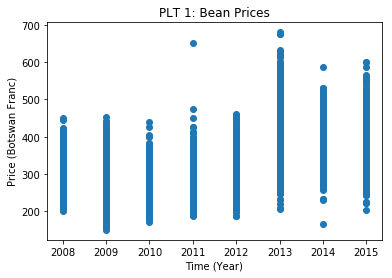

In [14]:
# plot showing yearly trend (little trend over different years)
plt.scatter(date_price.year, date_price.price)
plt.title("PLT 1: Bean Prices")
plt.xlabel("Time (Year)")
plt.ylabel("Price (Botswan Franc)")
plt.show()

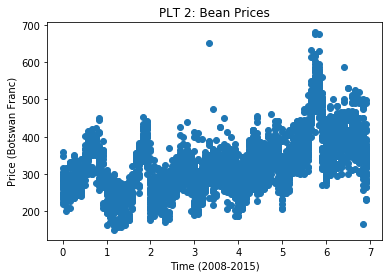

In [15]:
plt.scatter(train_time, train_price)
plt.title("PLT 2: Bean Prices")
plt.xlabel("Time (2008-2015)")
plt.ylabel("Price (Botswan Franc)")
plt.show()

The first market (mkt_id = 1046) is plotted below in plots 3 and 4 to show the trends and variation over the entire period where data is available. There is a consistent trend that the prices dip the lowest at the beginning and end of each year, and peak in the summertime. The inconsistency in relationship is shown over multiple years as the maximum and minimum values range between almost 200-500 Rwandan Francs), setting off alarm bells in the viability of any regression technique.

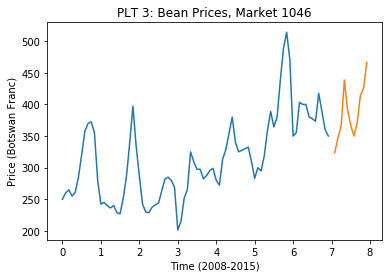

In [16]:
# inspecting the data looking at one market
plt.plot(train_time[:81], train_price[:81])
plt.plot(test_time[1:12], test_price[1:12])
plt.title("PLT 3: Bean Prices, Market 1046")
plt.xlabel("Time (2008-2015)")
plt.ylabel("Price (Botswan Franc)")
plt.show()

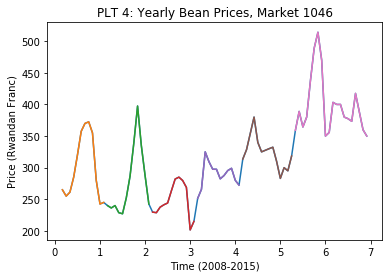

In [17]:
# looking at yearly trends in a single market
plt.plot(train_time[2:81], train_price[2:81])
plt.plot(train_time[2:14], train_price[2:14])
plt.plot(train_time[14:26], train_price[14:26])
plt.plot(train_time[26:38], train_price[26:38])
plt.plot(train_time[38:50], train_price[38:50])
plt.plot(train_time[50:62], train_price[50:62])
plt.plot(train_time[62:81], train_price[62:81])
plt.title("PLT 4: Yearly Bean Prices, Market 1046")
plt.xlabel("Time (2008-2015)")
plt.ylabel("Price (Rwandan Franc)")
plt.show()

Making an initial comparison of various markets, the prices in the training dataset are plotted on top of each other. This overlay shows there is significant agreement in market prices from market 1047 and 1048 over the same time period, giving me the impression that predicting another market during the same period might not be so difficult. That question, however, only tackles predicting a different market for the same period. Due to the differences in max/min overall for markets, it seems unlikely to find any trend over these years to predict into the future. 

Not all hope is lost!

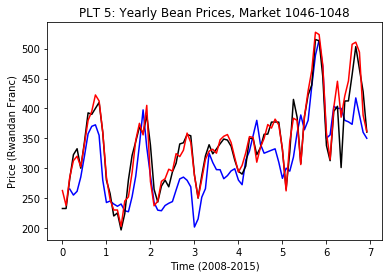

In [18]:
# plot multiple markets 
plt.plot(train_time[2:81], train_price[2:81], color="blue")
plt.plot(train_time[81:163], train_price[81:163], color ="black")
plt.plot(train_time[163:247], train_price[163:247], color ="red")
plt.title("PLT 5: Yearly Bean Prices, Market 1046-1048")
plt.xlabel("Time (2008-2015)")
plt.ylabel("Price (Rwandan Franc)")
plt.show()

# Ridge Regression

The first technique I implement is Ridge Regression, a model that typically works to ameliorate multicolliniarity, an issue not present with our single variable predictor – time. The output "Coefficient" is singular in this scenario, but given more variables the outputs can be tested in a cross-validation method to optimize the performance. The metrics for understanding performance include the mean squared error. In this scenario, MSE = 163,130. Wow! Plot 6 shows the regression line in black overlaying the data of market prices for the yera 2015, included in our test set. 

In [19]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import numpy as np

gamma_day = 1.0
center1 = np.linspace(0, 8, 100).reshape(-1, 1)

rbf_kern = rbf_kernel(train_time, center1, gamma = gamma_day)

# print x1, x2
# print x1.shape, x2.shape

In [21]:
alpha_full = .01
regr = Ridge(alpha=alpha_full, fit_intercept=True)


regr_full_model = regr.fit(train_time, train_price)
print"Score on training data for the full model: ", regr.score(train_time, train_price)

test_rbf = rbf_kernel(test_time, center1, gamma = gamma_day)

regr_y_pred = regr.predict(test_time)

print "Score on test data for the full model: ", regr.score(test_time, test_price)
print "MSE: ", mean_squared_error(test_price, regr_y_pred)

Score on training data for the full model:  0.312706938572
Score on test data for the full model:  0.000888875839899
MSE:  4727.47901547


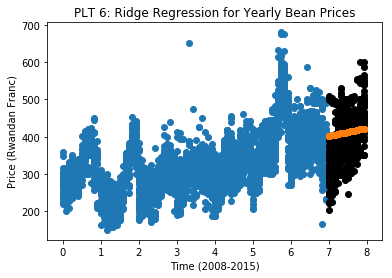

In [22]:
plt.figure()
plt.scatter(train_time, train_price)
plt.scatter(test_time, test_price, color="black")
plt.scatter(test_time, regr_y_pred)
plt.title("PLT 6: Ridge Regression for Yearly Bean Prices")
plt.xlabel("Time (2008-2015)")
plt.ylabel("Price (Rwandan Franc)")
plt.show()

# Gaussian Processes

After failing with ridge regression, GPy found it's way into the process, with an RBF kernel using a variance of 10 and lengthscale 0.01 (surrounding months likely have an effect on the ability to predict). Looking at the initial plots, the model falls short of the datapoints, but seems to spike in the accurate locations, the bit that reminded me of Sparse Gaussian Processes. The final metric for this GPy was the mean squared error, shown below as 55.69. Surprising! Given the plot that has no confidence interval, but doesn't align with the data, I am sceptical of these final results. They, however, the best results I achieved. 

In [23]:
import GPy
from GPy.models import GPRegression
import numpy as np
from sklearn.metrics import mean_squared_error

In [33]:
k = GPy.kern.RBF(input_dim=1, variance=10, lengthscale = 0.2)
full_model = GPy.models.GPRegression(train_time, 
                                  train_price, 
                                  kernel = k)

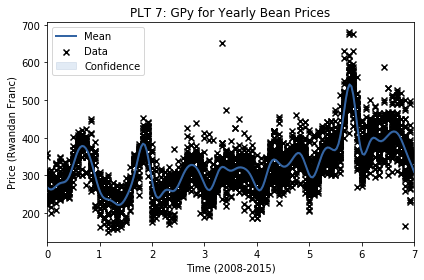


Name : GP regression
Objective : 2911490.26505
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |  value  |  constraints  |  priors
  rbf.variance             |   10.0  |      +ve      |        
  rbf.lengthscale          |    0.2  |      +ve      |        
  Gaussian_noise.variance  |    1.0  |      +ve      |        


In [34]:
full_model.plot(plot_limits=[0, 7])
plt.title("PLT 7: GPy for Yearly Bean Prices")
plt.xlabel("Time (2008-2015)")
plt.ylabel("Price (Rwandan Franc)")
plt.show()
print full_model

In [35]:
pred = full_model.predict(test_time)
print "GPY MSE: ", mean_squared_error(test_time, pred[0])

GPY MSE:  17368.8883757


# Sparse Gaussian Processes

Sparse Gaussian Processes follow a similar method as Gaussian Processes, but fit fewer concentrated areas of data. Using the same kernel as above, the plots (8 before optimization, 9 after) become equally as confusing – the model is dramatically off from the data except with regard to spikes. The MSE, however are much better, closer to values of 55 in both cases. When the lengthscale and noise variance are increased, the graphs make a lot more sense in terms of shaping the general trend, but the MSE increases by a few magnitudes. 

In [27]:
from GPy.models import SparseGPRegression

In [36]:
num_ind = 50
k = GPy.kern.RBF(input_dim=1, lengthscale=0.2)
noise_var = 10
sparse_gpy = GPy.models.SparseGPRegression(train_time,
                                          train_price,
                                          kernel = k,
                                          num_inducing = num_ind)

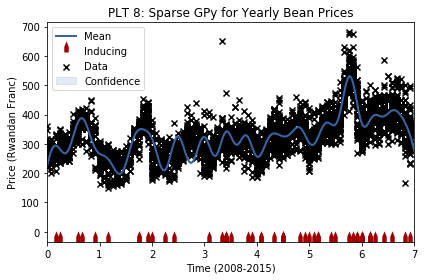


Name : sparse_gp
Objective : 4539962.44776
Number of Parameters : 53
Number of Optimization Parameters : 53
Updates : True
Parameters:
  sparse_gp.               |    value  |  constraints  |  priors
  inducing_inputs          |  (50, 1)  |               |        
  rbf.variance             |      1.0  |      +ve      |        
  rbf.lengthscale          |      0.2  |      +ve      |        
  Gaussian_noise.variance  |      1.0  |      +ve      |        


In [37]:
sparse_gpy.plot(plot_data=True, plot_limits=[0,7])
plt.title("PLT 8: Sparse GPy for Yearly Bean Prices")
plt.xlabel("Time (2008-2015)")
plt.ylabel("Price (Rwandan Franc)")
plt.show()
print sparse_gpy

In [38]:
sparse_pred = sparse_gpy.predict(test_time)
print "Sparse GPY MSE: ", mean_squared_error(test_time, sparse_pred[0])

Sparse GPY MSE:  10844.7773589


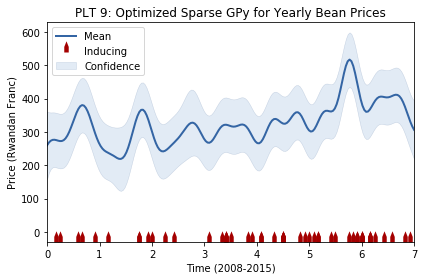


Name : sparse_gp
Objective : 18674.8805508
Number of Parameters : 53
Number of Optimization Parameters : 3
Updates : True
Parameters:
  sparse_gp.               |           value  |  constraints  |  priors
  inducing_inputs          |         (50, 1)  |     fixed     |        
  rbf.variance             |   42797.4785707  |      +ve      |        
  rbf.lengthscale          |  0.316312812281  |      +ve      |        
  Gaussian_noise.variance  |   1728.65874681  |      +ve      |        


In [39]:
sparse_gpy.inducing_inputs.fix()
sparse_gpy.optimize("bfgs")
sparse_gpy.plot(plot_data=False, plot_limits=[0,7])
plt.title("PLT 9: Optimized Sparse GPy for Yearly Bean Prices")
plt.xlabel("Time (2008-2015)")
plt.ylabel("Price (Rwandan Franc)")
plt.show()
print sparse_gpy

In [40]:
sparse_y_pred_opt = sparse_gpy.predict(test_time)
print "Optimized Sparce GPY MSE: ", mean_squared_error(test_time, sparse_y_pred_opt[0])

Optimized Sparce GPY MSE:  43504.3819446


## Standard Vector Regression

The final model implemented is Standard Vector Regression. This technique is similar to that of Standard Vector Machines, used for classification problems, by pushing boundaries against the inner-most data points of each class to create the widest separation. Instead of finding the widest seperation between classes, the margins are used as metrics of error, and try to fit where the error is minimized. In Plot 10 below the output of SVR are shown in orange, a line with a clear deviation from the actual data in black – following the trend of the previous years dramatic decline. 

In [391]:
from sklearn.svm import SVR
svr = SVR(kernel='rbf')
svr.fit(train_time, train_price) 

SVR(C=1.0, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma='auto',
  kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

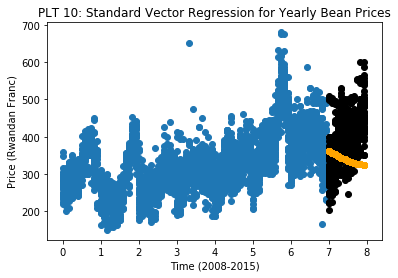

In [560]:
plt.scatter(train_time, train_price)
plt.scatter(test_time, test_price, color="black")
plt.scatter(test_time, svr_y_pred, color="orange")
plt.title("PLT 10: Standard Vector Regression for Yearly Bean Prices")
plt.xlabel("Time (2008-2015)")
plt.ylabel("Price (Rwandan Franc)")
plt.show()

In [405]:
svr_y_pred = svr.predict(test_time)
print "Score on training data for the full model: ", svr.score(train_time, train_price)
print "Score on test data for the full model: ", svr.score(test_time, test_price)
print "MSE: ", mean_squared_error(test_price, svr_y_pred)

Score on training data for the full model:  0.437213237578
Score on test data for the full model:  -0.77004610054
MSE:  8375.30039889


Overall, none of these techniques worked sufficiently, with the current parameters and setup of the problem. This was the first step in what would surely be a much larger invetigation into a variety of other parameters, cross-validation methods, grid searches, time complexity questions, and finding practical outcomes. The biggest issues I faced with this dataset were formatting and discovering a problem, or bits of information that are useful to understand. In the end, the trend in the data over this time period was not sufficiently fit – as the predictions tend to follow the downward slope of year 2014.